<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/Project23_Reinforcement_Learning_Proximal_Policy_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install stable-baselines3[extra]
!pip install gymnasium
!pip install shimmy
!pip install ccxt



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO

import ccxt




In [6]:
exchange = ccxt.kucoin()


bars = exchange.fetch_ohlcv(
    'BTC/USDT',
    timeframe='1h',
    limit=1000
)



df = pd.DataFrame(
    bars,
    columns=['timestamp',  'open',  'high',  'low',  'close',  'volume']
)


df['timestamp']  = pd.to_datetime(df['timestamp'],  unit='ms')


df.head()

,timestamp,open,high,low,close,volume
0,2026-04-02 04:00:00,66580.5,66654.9,66225.9,66342.1,77.311959
1,2026-04-02 05:00:00,66342.2,66645.0,66313.7,66601.3,69.321546
2,2026-04-02 06:00:00,66601.4,66817.0,66549.8,66685.6,63.123449
3,2026-04-02 07:00:00,66685.6,66934.7,66562.0,66927.8,41.061619
4,2026-04-02 08:00:00,66927.7,66927.7,66399.3,66450.5,66.403445


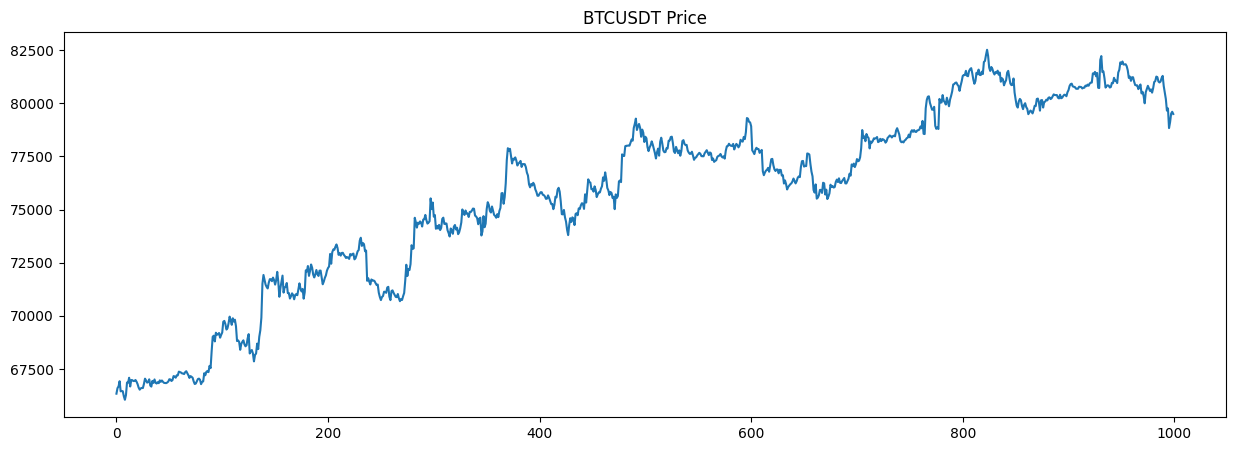

In [7]:
plt.figure(figsize=(15,5))

plt.plot(df['close'])

plt.title('BTCUSDT Price')
plt.show()



In [8]:
df['ema20'] = df['close'].ewm(span=20).mean()
df['ema50'] = df['close'].ewm(span=50).mean()



In [10]:
delta = df['close'].diff()


gain = (delta.where( delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0 , 0)).rolling(14).mean()


rs = gain/loss


df['rsi'] = 100 - (100 / (1+rs)   )

df

,timestamp,open,high,low,close,volume,ema20,ema50,rsi
0,2026-04-02 04:00:00,66580.5,66654.9,66225.9,66342.1,77.311959,66342.100000,66342.100000,NaN
1,2026-04-02 05:00:00,66342.2,66645.0,66313.7,66601.3,69.321546,66478.180000,66474.292000,NaN
2,2026-04-02 06:00:00,66601.4,66817.0,66549.8,66685.6,63.123449,66554.343381,66547.563845,NaN
3,2026-04-02 07:00:00,66685.6,66934.7,66562.0,66927.8,41.061619,66662.154532,66648.400922,NaN
4,2026-04-02 08:00:00,66927.7,66927.7,66399.3,66450.5,66.403445,66610.957102,66605.592306,NaN
...,...,...,...,...,...,...,...,...,...
995,2026-05-13 15:00:00,79763.0,79857.7,78817.5,78834.2,150.119567,80464.481733,80741.018616,19.112745
996,2026-05-13 16:00:00,78834.1,79231.6,78771.9,79109.9,102.791861,80335.473949,80677.053180,24.178730
997,2026-05-13 17:00:00,79112.8,79563.0,79104.9,79517.2,61.389617,80257.543097,80631.568742,27.908276
998,2026-05-13 18:00:00,79521.3,79799.9,79521.3,79601.4,49.823764,80195.053278,80591.169967,29.619246
